# Bivariate Analysis

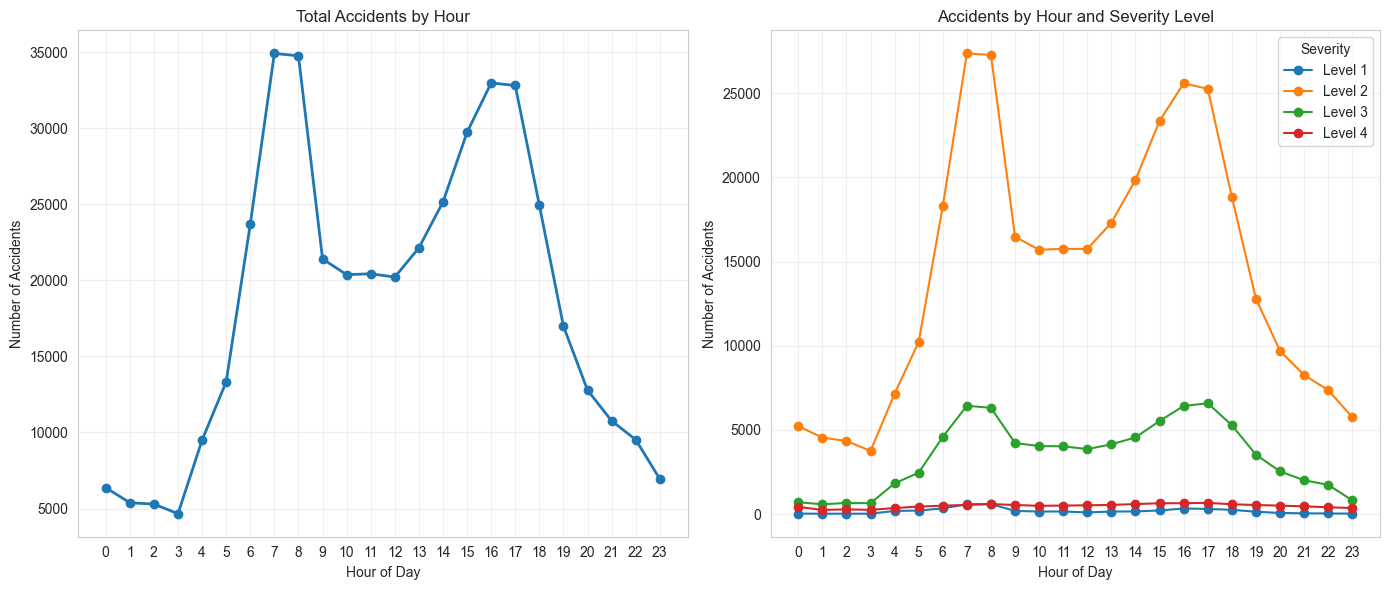

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# 1. Accidents by Hour and Severity
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# Count of accidents by hour
hour_counts = df_clean.groupby('Hour').size()
plt.plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.title('Total Accidents by Hour')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Severity distribution by hour
severity_by_hour = df_clean.groupby(['Hour', 'Severity']).size().unstack(fill_value=0)
severity_by_hour.plot(kind='line', marker='o', ax=plt.gca())
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.title('Accidents by Hour and Severity Level')
plt.legend(title='Severity', labels=['Level 1', 'Level 2', 'Level 3', 'Level 4'])
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.savefig('results/figures/bivariate/01_accidents_by_hour_and_severity.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

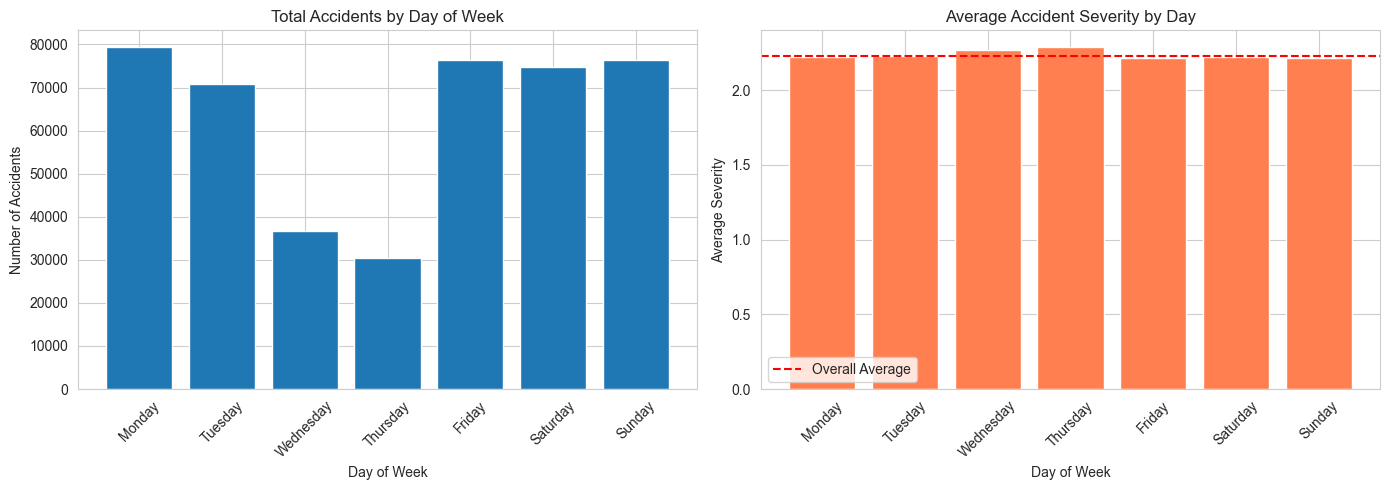

In [85]:
# 2. Accidents by Day of Week
plt.figure(figsize=(14, 5))

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.subplot(1, 2, 1)
# Total by day
day_counts = df_clean['Day_of_Week'].value_counts().sort_index()
plt.bar(range(7), day_counts.values)
plt.xlabel('Day of Week')
plt.ylabel('Number of Accidents')
plt.title('Total Accidents by Day of Week')
plt.xticks(range(7), day_names, rotation=45)

plt.subplot(1, 2, 2)
# Average severity by day
avg_severity_by_day = df_clean.groupby('Day_of_Week')['Severity'].mean()
plt.bar(range(7), avg_severity_by_day.values, color='coral')
plt.xlabel('Day of Week')
plt.ylabel('Average Severity')
plt.title('Average Accident Severity by Day')
plt.xticks(range(7), day_names, rotation=45)
plt.axhline(y=df_clean['Severity'].mean(), color='red', linestyle='--', label='Overall Average')
plt.legend()
plt.savefig('results/figures/bivariate/02_accidents_by_day_of_week.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

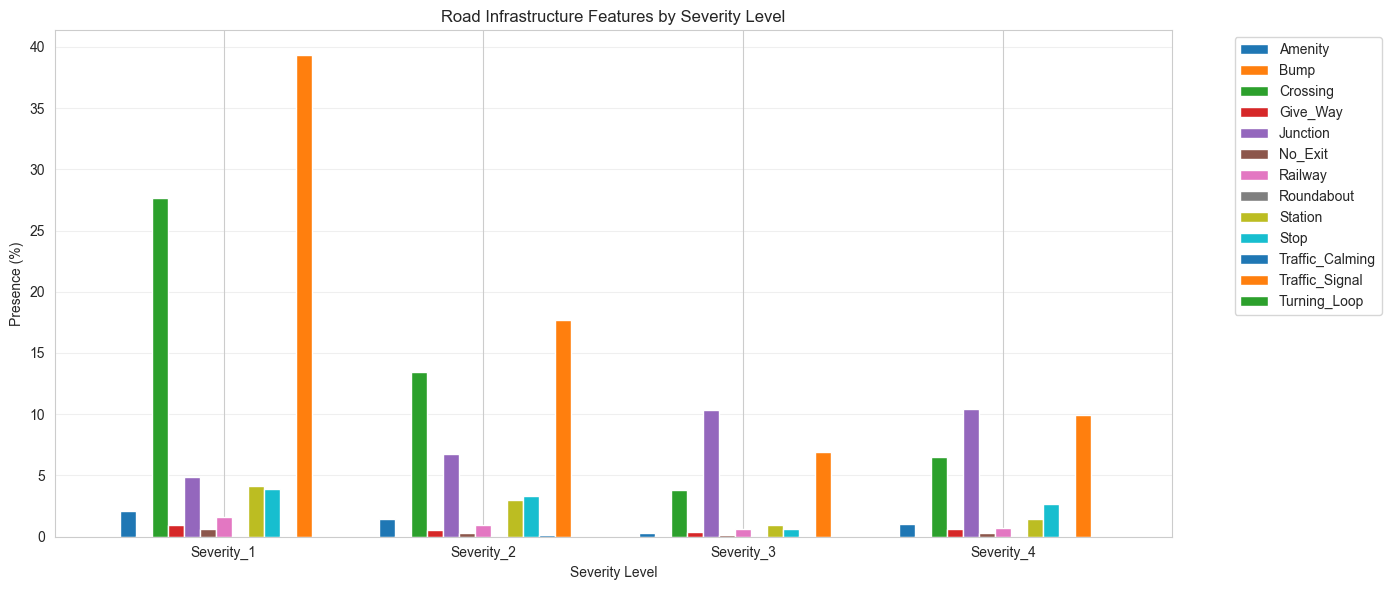


POI presence by severity (%):
             Amenity      Bump   Crossing  Give_Way   Junction   No_Exit  \
Severity_1  2.058684  0.047326  27.614766  0.922858   4.874586  0.591576   
Severity_2  1.469882  0.045681  13.469200  0.507693   6.739371  0.275531   
Severity_3  0.329689  0.023977   3.787225  0.350070  10.304273  0.134273   
Severity_4  1.012373  0.034611   6.463615  0.588388  10.452540  0.311500   

             Railway  Roundabout   Station      Stop  Traffic_Calming  \
Severity_1  1.632750    0.000000  4.117369  3.880738         0.070989   
Severity_2  0.925182    0.002891  3.022164  3.337015         0.103505   
Severity_3  0.643792    0.000000  0.954299  0.618616         0.057546   
Severity_4  0.718179    0.000000  1.401748  2.621788         0.069222   

            Traffic_Signal  Turning_Loop  
Severity_1       39.375296           0.0  
Severity_2       17.686583           0.0  
Severity_3        6.888697           0.0  
Severity_4        9.916068           0.0  


In [86]:
# POI features vs Severity
poi_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 
                'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 
                'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']

# Calculate percentage of each POI for each severity level
poi_severity = pd.DataFrame()
for severity in [1, 2, 3, 4]:
    poi_severity[f'Severity_{severity}'] = df_clean[df_clean['Severity'] == severity][poi_features].mean() * 100

# Plot
plt.figure(figsize=(14, 6))
poi_severity.T.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.xlabel('Severity Level')
plt.ylabel('Presence (%)')
plt.title('Road Infrastructure Features by Severity Level')
plt.legend(poi_features, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('results/figures/bivariate/03_poi_presence_by_severity.png', dpi=300, bbox_inches='tight')  
plt.show()

print("\nPOI presence by severity (%):")
print(poi_severity.T)

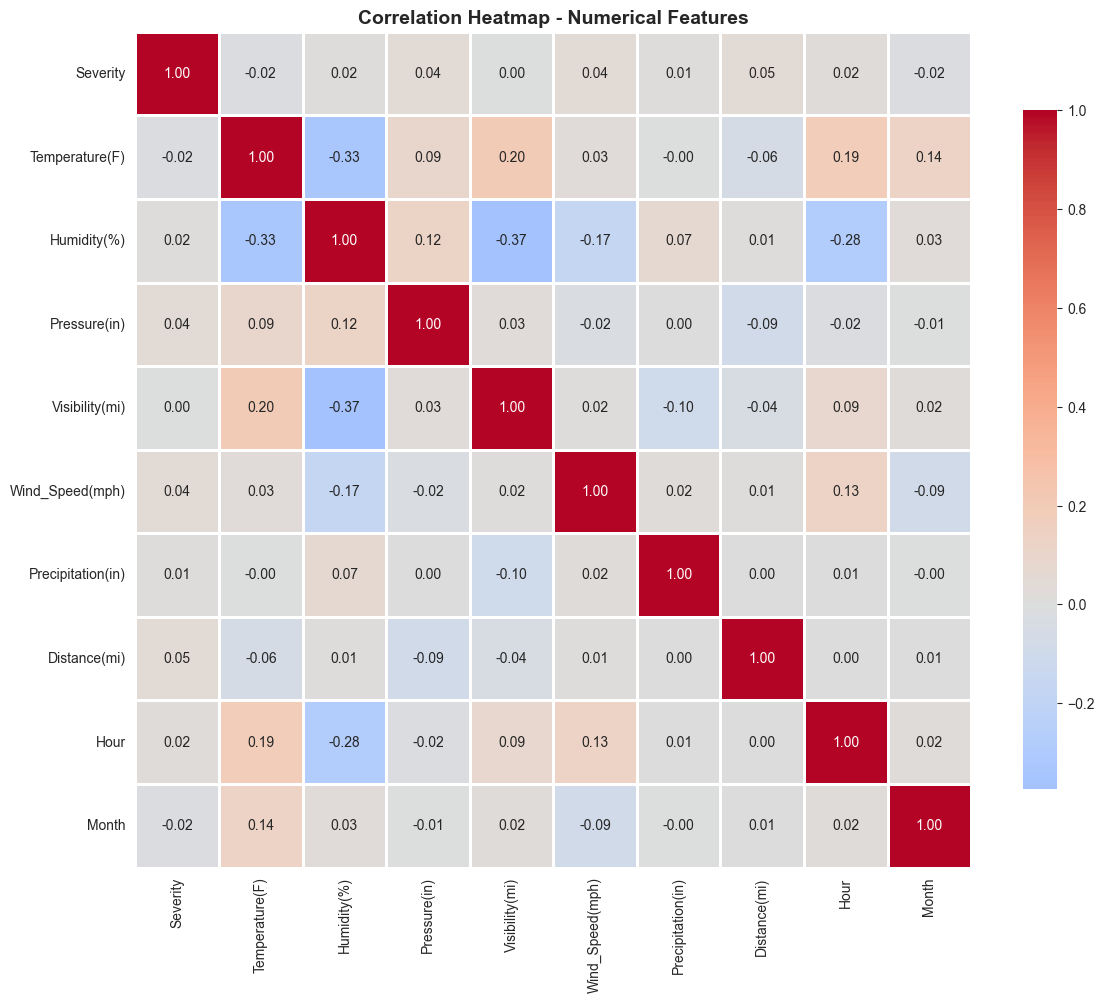


Correlations with Severity (sorted by absolute value):
Severity             1.000000
Distance(mi)         0.047071
Pressure(in)         0.043856
Wind_Speed(mph)      0.041368
Hour                 0.020110
Humidity(%)          0.016277
Precipitation(in)    0.010337
Visibility(mi)       0.000188
Month               -0.017072
Temperature(F)      -0.018379
Name: Severity, dtype: float64


In [87]:
# Select numerical features for correlation
numerical_features = ['Severity', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
                      'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
                      'Distance(mi)', 'Hour', 'Month']

# Calculate correlation matrix
correlation_matrix = df_clean[numerical_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/bivariate/04_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print top correlations with Severity
print("\nCorrelations with Severity (sorted by absolute value):")
severity_corr = correlation_matrix['Severity'].sort_values(ascending=False)
print(severity_corr)

<Figure size 1400x600 with 0 Axes>

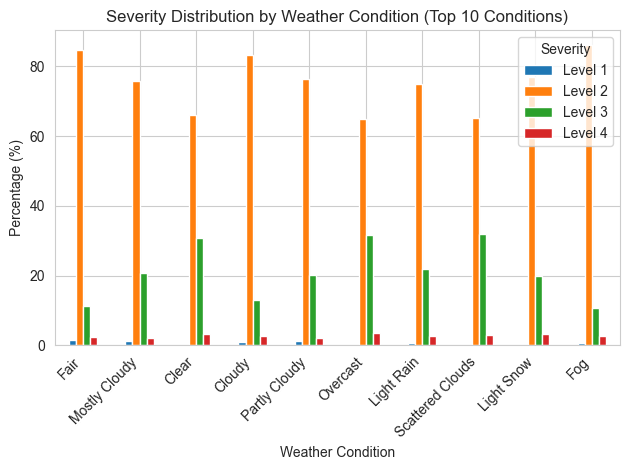


Severity distribution by weather condition (%):
Severity                  1          2          3         4
Weather_Condition                                          
Fair               1.477529  84.745195  11.420070  2.357206
Mostly Cloudy      1.175442  75.948005  20.660198  2.216355
Clear              0.045858  65.921467  30.772905  3.259769
Cloudy             1.065364  83.186622  13.074920  2.673095
Partly Cloudy      1.143568  76.487370  20.157515  2.211548
Overcast           0.028117  64.813625  31.507069  3.651189
Light Rain         0.727641  74.937355  21.781033  2.553971
Scattered Clouds   0.030701  65.116279  31.921099  2.931921
Light Snow         0.083496  76.829947  19.774562  3.311996
Fog                0.574513  86.020195  10.776462  2.628830


In [88]:
# Weather Condition (categorical) vs Severity
weather_severity = pd.crosstab(df_clean['Weather_Condition'], df_clean['Severity'], 
                                normalize='index') * 100

# Get top 10 most common weather conditions
top_weather = df_clean['Weather_Condition'].value_counts().head(10).index
weather_severity_top = weather_severity.loc[top_weather]

# Plot
plt.figure(figsize=(14, 6))
weather_severity_top.plot(kind='bar', stacked=False)
plt.xlabel('Weather Condition')
plt.ylabel('Percentage (%)')
plt.title('Severity Distribution by Weather Condition (Top 10 Conditions)')
plt.legend(title='Severity', labels=['Level 1', 'Level 2', 'Level 3', 'Level 4'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/figures/bivariate/05_severity_by_weather_condition.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSeverity distribution by weather condition (%):")
print(weather_severity_top)

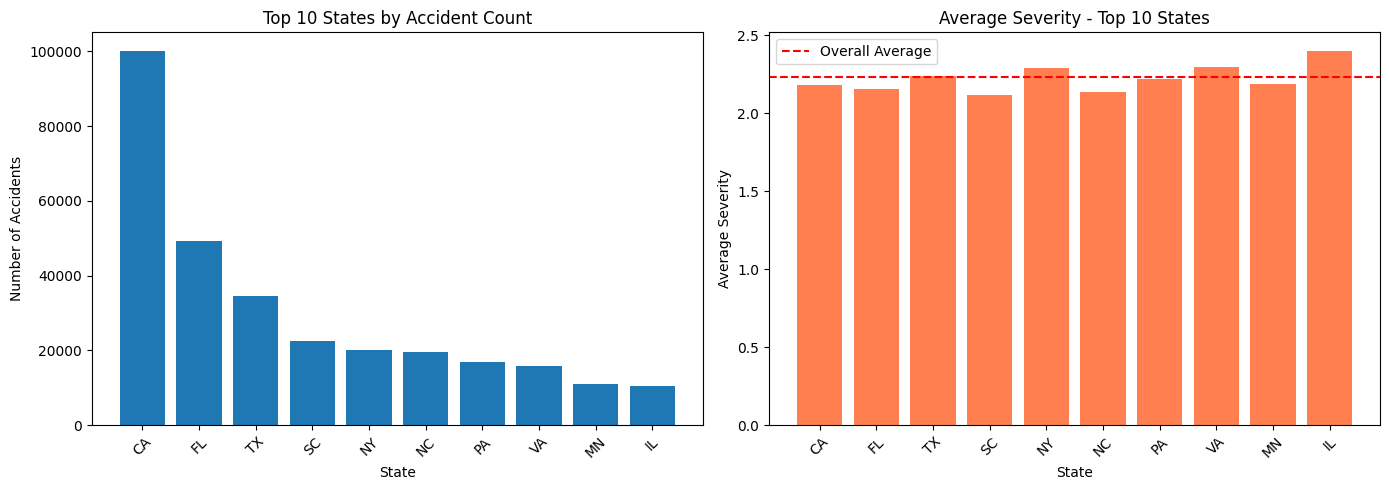


Top 10 States:
           mean   count
State                  
CA     2.183313  100102
FL     2.156935   49167
TX     2.235473   34522
SC     2.119764   22369
NY     2.286720   20030
NC     2.133089   19656
PA     2.216619   16776
VA     2.299114   15917
MN     2.185610   10910
IL     2.398714   10421


In [15]:
# Geographic analysis - State vs Severity
state_severity = df_clean.groupby('State')['Severity'].agg(['mean', 'count']).sort_values('count', ascending=False)
top_states = state_severity.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 states by accident count
axes[0].bar(range(10), top_states['count'].values)
axes[0].set_xlabel('State')
axes[0].set_ylabel('Number of Accidents')
axes[0].set_title('Top 10 States by Accident Count')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(top_states.index, rotation=45)

# Average severity by top 10 states
axes[1].bar(range(10), top_states['mean'].values, color='coral')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Average Severity')
axes[1].set_title('Average Severity - Top 10 States')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(top_states.index, rotation=45)
axes[1].axhline(y=df_clean['Severity'].mean(), color='red', linestyle='--', label='Overall Average')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/figures/bivariate/06_severity_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 States:")
print(top_states)